In [1]:
# Kaggle setup. Pin this branch/commit before the final run.
!git clone -b version2 https://github.com/Briannguyen3106/flood-forecast.git
%cd flood-forecast
!pip install -r requirements.txt

Cloning into 'flood-forecast'...
remote: Enumerating objects: 406, done.
remote: Counting objects: 100% (406/406), done.
remote: Compressing objects: 100% (309/309), done.
remote: Total 406 (delta 184), reused 206 (delta 90), pack-reused 0 (from 0)
Receiving objects: 100% (406/406), 25.49 MiB | 16.68 MiB/s, done.
Resolving deltas: 100% (184/184), done.
/kaggle/working/flood-forecast


In [2]:
# CELL 1 - Setup
import json
import os
import pickle
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.core.data_preprocessing import (
    PipelineA,
    PipelineB,
    RISK_CLASS_TO_INT,
    assign_class,
)
from src.core.trainer import Trainer
from src.model.decision_tree_classifier import DecisionTreeClassifierModel
from src.model.hist_gradient_boosting_classifier import HistGradientBoostingClassifierModel
from src.model.huber_regression import HuberRegressionModel
from src.model.lasso_regression import LassoRegressionModel
from src.model.lgbm_scratch_v2 import LGBMScratchModel
from src.model.linear_regression import LinearRegressionModel
from src.model.random_forest_classifier import RandomForestClassifierModel
from src.model.ridge_regression import RidgeRegressionModel
from src.model.svm_classifier import SVMClassifierModel
from src.model.xgb_classifier import XGBClassifierModel
from src.model.xgbrf_classifier import XGBRFClassifierModel

RANDOM_STATE = 42
N_ITER = 100
CV_SPLITS = 5
CV_REPEATS = 1
ARTIFACT_SCHEMA_VERSION = 1

RESULTS_DIR = PROJECT_ROOT / 'results' / 'final'
MODELS_DIR = PROJECT_ROOT / 'saved_models'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Optional: directory mounted from a previous Kaggle Output/Dataset.
# Example: Path('/kaggle/input/flood-model-checkpoints/saved_models')
EXTERNAL_MODELS_DIR = None

def get_code_revision():
    try:
        return subprocess.check_output(
            ['git', 'rev-parse', 'HEAD'], cwd=PROJECT_ROOT, text=True
        ).strip()
    except Exception:
        return 'unknown'

CODE_REVISION = get_code_revision()
print(f'Project root: {PROJECT_ROOT}')
print(f'Code revision: {CODE_REVISION}')

Project root: /kaggle/working/flood-forecast
Code revision: 86a64936223ca75f3b580523ec80c0ae3e08b42b


In [3]:
# CELL 2 - Load raw train/test splits
raw_train = pd.read_csv(PROJECT_ROOT / 'data' / 'splits' / 'train.csv')
raw_test = pd.read_csv(PROJECT_ROOT /  'data' / 'splits' / 'test.csv')

for split_name, frame in [('train', raw_train), ('test', raw_test)]:
    if 'risk_labels' not in frame.columns:
        raise ValueError(f'{split_name} split is not raw data: risk_labels is missing')

train_classes = raw_train['risk_labels'].apply(assign_class)
print(f'Raw train: {raw_train.shape}')
print(f'Raw test : {raw_test.shape}')
print('\nTrain class distribution:')
print(train_classes.value_counts().reindex(['Low', 'Medium', 'High']))
print(f'\nTarget mapping: {RISK_CLASS_TO_INT}')

Raw train: (2370, 18)
Raw test : (593, 18)

Train class distribution:
risk_labels
Low       1595
Medium     459
High       316
Name: count, dtype: int64

Target mapping: {'Low': 0, 'Medium': 1, 'High': 2}


In [4]:
# CELL 3 - Frozen per-model configurations selected by train-only ablation
W_MODERATE = {0: 1.0, 1: 1.5, 2: 2.0}
W_RISK = {0: 1.0, 1: 2.0, 2: 3.0}

ALL_MODEL_CONFIGS = {
    'DecisionTree': {
        'model_factory': DecisionTreeClassifierModel,
        'preprocessor_factory': lambda: PipelineA(fe_groups=['G3']),
        'config_name': 'PA_G3_none', 'imbalance': 'none', 'class_weights': None,
    },
    'RandomForest': {
        'model_factory': RandomForestClassifierModel,
        'preprocessor_factory': lambda: PipelineA(fe_groups=[]),
        'config_name': 'PA_base_smote', 'imbalance': 'smote', 'class_weights': None,
    },
    'XGBoost': {
        'model_factory': XGBClassifierModel,
        'preprocessor_factory': lambda: PipelineA(fe_groups=['G3']),
        'config_name': 'PA_G3_none', 'imbalance': 'none', 'class_weights': None,
    },
    'XGBRF': {
        'model_factory': XGBRFClassifierModel,
        'preprocessor_factory': lambda: PipelineA(fe_groups=[]),
        'config_name': 'PA_base_smote', 'imbalance': 'smote', 'class_weights': None,
    },
    'LightGBM': {
        'model_factory': LGBMScratchModel,
        'preprocessor_factory': lambda: PipelineA(fe_groups=['G3']),
        'config_name': 'PA_G3_none', 'imbalance': 'none', 'class_weights': None,
    },
    'HistGB': {
        'model_factory': HistGradientBoostingClassifierModel,
        'preprocessor_factory': lambda: PipelineA(fe_groups=['G3']),
        'config_name': 'PA_G3_balanced', 'imbalance': 'none', 'class_weights': None,
    },
    'LinearRegression': {
        'model_factory': LinearRegressionModel,
        'preprocessor_factory': lambda: PipelineB(
            fe_groups=[], use_skew=False, use_scale=True, use_ohe=False
        ),
        'config_name': 'scale_w1152', 'imbalance': 'weighted',
        'class_weights': W_MODERATE,
    },
    'Ridge': {
        'model_factory': RidgeRegressionModel,
        'preprocessor_factory': lambda: PipelineB(
            fe_groups=[], use_skew=False, use_scale=True, use_ohe=False
        ),
        'config_name': 'scale_base_none', 'imbalance': 'none', 'class_weights': None,
    },
    'Lasso': {
        'model_factory': LassoRegressionModel,
        'preprocessor_factory': lambda: PipelineB(
            fe_groups=[], use_skew=False, use_scale=False, use_ohe=True
        ),
        'config_name': 'ohe_base_none', 'imbalance': 'none', 'class_weights': None,
    },
    'Huber': {
        'model_factory': HuberRegressionModel,
        'preprocessor_factory': lambda: PipelineB(
            fe_groups=[], use_skew=False, use_scale=True, use_ohe=False
        ),
        'config_name': 'scale_w1152', 'imbalance': 'weighted',
        'class_weights': W_MODERATE,
    },
    'SVM': {
        'model_factory': SVMClassifierModel,
        'preprocessor_factory': lambda: PipelineB(
            fe_groups=[], use_skew=True, use_scale=True, use_ohe=False
        ),
        'config_name': 'scale_skew_w123', 'imbalance': 'weighted',
        'class_weights': W_RISK,
    },
}

TREE_MODELS = ['DecisionTree', 'RandomForest', 'XGBoost', 'XGBRF', 'LightGBM', 'HistGB']
LINEAR_MODELS = ['LinearRegression', 'Ridge', 'Lasso', 'Huber', 'SVM']

print(f'Frozen configurations: {len(ALL_MODEL_CONFIGS)} models')
for name, spec in ALL_MODEL_CONFIGS.items():
    print(f"  {name:18s} {spec['config_name']}")

Frozen configurations: 11 models
  DecisionTree       PA_G3_none
  RandomForest       PA_base_smote
  XGBoost            PA_G3_none
  XGBRF              PA_base_smote
  LightGBM           PA_G3_none
  HistGB             PA_G3_balanced
  LinearRegression   scale_w1152
  Ridge              scale_base_none
  Lasso              ohe_base_none
  Huber              scale_w1152
  SVM                scale_skew_w123


In [5]:
# CELL 4 - Checkpoint and evaluation helpers
def expected_metadata(model_name, spec):
    return {
        'artifact_schema_version': ARTIFACT_SCHEMA_VERSION,
        'model_class': spec['model_factory']().__class__.__name__,
        'target_mapping': RISK_CLASS_TO_INT,
        'config_name': spec['config_name'],
        'imbalance': spec['imbalance'],
        'class_weights': spec['class_weights'],
        'n_iter': N_ITER,
        'cv_splits': CV_SPLITS,
        'cv_repeats': CV_REPEATS,
        'random_state': RANDOM_STATE,
    }

def artifact_candidates(model_name):
    paths = [MODELS_DIR / f'{model_name}.pkl']
    if EXTERNAL_MODELS_DIR is not None:
        paths.append(Path(EXTERNAL_MODELS_DIR) / f'{model_name}.pkl')
    return paths

def validate_artifact(pipeline, model_name, spec):
    metadata = getattr(pipeline, 'metadata', None)
    if not isinstance(metadata, dict):
        return False, 'missing metadata (historical artifact)'
    for key, expected in expected_metadata(model_name, spec).items():
        if metadata.get(key) != expected:
            return False, f'{key}: saved={metadata.get(key)!r}, expected={expected!r}'
    if not hasattr(pipeline, 'predict') or not hasattr(pipeline, 'preprocessor'):
        return False, 'artifact is not a raw-row pipeline'
    return True, 'compatible'

def load_compatible_artifact(model_name, spec):
    for path in artifact_candidates(model_name):
        if not path.exists():
            continue
        try:
            with open(path, 'rb') as handle:
                pipeline = pickle.load(handle)
            valid, reason = validate_artifact(pipeline, model_name, spec)
        except Exception as exc:
            print(f'  Reject {path}: cannot load ({exc})')
            continue
        if valid:
            saved_revision = pipeline.metadata.get('code_revision', 'unknown')
            if saved_revision != CODE_REVISION:
                print(
                    f'  Warning: checkpoint revision {saved_revision!r} differs '
                    f'from current {CODE_REVISION!r}; accepting because model '
                    'contract metadata matches'
                )
            print(f'  Loaded compatible checkpoint: {path}')
            return pipeline
        print(f'  Reject {path}: {reason}')
    return None

def save_artifact_atomic(pipeline, model_name):
    final_path = MODELS_DIR / f'{model_name}.pkl'
    temp_path = MODELS_DIR / f'.{model_name}.pkl.tmp'
    with open(temp_path, 'wb') as handle:
        pickle.dump(pipeline, handle, protocol=pickle.HIGHEST_PROTOCOL)
        handle.flush()
        os.fsync(handle.fileno())
    temp_path.replace(final_path)
    print(f'  Checkpoint saved: {final_path}')
    return final_path

def evaluate_split(pipeline, raw_df):
    y_true = raw_df['risk_labels'].apply(assign_class).map(RISK_CLASS_TO_INT).to_numpy()
    y_pred = pipeline.predict(raw_df)
    return {
        'f2_macro': fbeta_score(y_true, y_pred, beta=2, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'y_true': y_true,
        'y_pred': y_pred,
    }

def detailed_test_metrics(model_name, pipeline):
    metrics = evaluate_split(pipeline, raw_test)
    report = classification_report(
        metrics['y_true'], metrics['y_pred'], labels=[0, 1, 2],
        target_names=['Low', 'Medium', 'High'], output_dict=True,
        zero_division=0,
    )
    return {
        'model': model_name,
        'f2_macro': metrics['f2_macro'],
        'f1_weighted': metrics['f1_weighted'],
        'per_class': report,
        'confusion_matrix': confusion_matrix(
            metrics['y_true'], metrics['y_pred'], labels=[0, 1, 2]
        ).tolist(),
        'best_params': pipeline.metadata.get('best_params'),
        'metadata': pipeline.metadata,
    }

print('Checkpoint helpers ready')

Checkpoint helpers ready


In [6]:
# CELL 5 - Train missing models or resume from compatible checkpoints
# This cell never reads the test split.
all_pipelines = {}
checkpoint_rows = []

for model_name, spec in ALL_MODEL_CONFIGS.items():
    print(f"\n{'=' * 64}\n{model_name}: {spec['config_name']}")
    pipeline = load_compatible_artifact(model_name, spec)
    source = 'checkpoint'

    if pipeline is None:
        source = 'trained'
        trainer = Trainer(
            model=spec['model_factory'](),
            preprocessor_factory=spec['preprocessor_factory'],
            imbalance=spec['imbalance'],
            class_weights=spec['class_weights'],
            n_iter=N_ITER,
            random_state=RANDOM_STATE,
            cv=CV_SPLITS,
            n_repeats=CV_REPEATS,
            config_name=spec['config_name'],
        )
        trainer.tune(raw_train)
        pipeline = trainer.pipeline
        pipeline.metadata['code_revision'] = CODE_REVISION
        save_artifact_atomic(pipeline, model_name)

    all_pipelines[model_name] = pipeline
    train_metrics = evaluate_split(pipeline, raw_train)
    checkpoint_rows.append({
        'Model': model_name,
        'Source': source,
        'Config': pipeline.metadata['config_name'],
        'CV F2-macro': pipeline.metadata['best_cv_f2_macro'],
        'Train F2-macro': train_metrics['f2_macro'],
        'Train F1-weighted': train_metrics['f1_weighted'],
    })

    # Small manifest remains readable even if a later model is interrupted.
    pd.DataFrame(checkpoint_rows).to_csv(
        RESULTS_DIR / 'training_checkpoint_manifest.csv', index=False
    )

print(f'\nReady artifacts: {len(all_pipelines)}/{len(ALL_MODEL_CONFIGS)}')


DecisionTree: PA_G3_none
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896 rows, fe_groups=['G3']...
[PipelineA] done — 11 features
[PipelineA] fitting on 1,896

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 45 is smaller than n_iter=100. Running 45 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=Fal

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 72 is smaller than n_iter=100. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=Fal

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 72 is smaller than n_iter=100. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=True, fe_groups=[]
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=True, fe_groups=[]
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=True, fe_groups=[]
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=True, fe_groups=[]
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=True, fe_groups=[]
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=True, fe_groups=[]
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=True, fe_groups=[]
[PipelineB] done — 30 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=False, use_ohe=Tr

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 72 is smaller than n_iter=100. Running 72 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=False, fe_groups=[]
[PipelineB] done — 10 features

[PipelineB] fitting on 1,896 rows...
  use_skew=False, use_scale=True, use_ohe=Fal

In [7]:
# CELL 6 - Training/CV checkpoint summary and final-evaluation gate
df_checkpoint = pd.DataFrame(checkpoint_rows)
display(df_checkpoint.style.format({
    'CV F2-macro': '{:.4f}',
    'Train F2-macro': '{:.4f}',
    'Train F1-weighted': '{:.4f}',
}))

missing_models = sorted(set(ALL_MODEL_CONFIGS) - set(all_pipelines))
if missing_models:
    raise RuntimeError(
        f'Final test is blocked; missing artifacts: {missing_models}'
    )

for model_name, spec in ALL_MODEL_CONFIGS.items():
    valid, reason = validate_artifact(all_pipelines[model_name], model_name, spec)
    if not valid:
        raise RuntimeError(f'Final test is blocked for {model_name}: {reason}')

print('All 11 artifacts are compatible. Final test evaluation is unlocked.')

,Model,Source,Config,CV F2-macro,Train F2-macro,Train F1-weighted
0,DecisionTree,trained,PA_G3_none,0.8966,0.9469,0.9597
1,RandomForest,trained,PA_base_smote,0.9003,0.9395,0.9429
2,XGBoost,trained,PA_G3_none,0.9020,0.9772,0.9790
3,XGBRF,trained,PA_base_smote,0.9030,0.9493,0.9507
4,LightGBM,trained,PA_G3_none,0.9098,0.9868,0.9886
5,HistGB,trained,PA_G3_balanced,0.9338,0.9639,0.9568
6,LinearRegression,trained,scale_w1152,0.6031,0.6036,0.6483
7,Ridge,trained,scale_base_none,0.5999,0.6043,0.6515
8,Lasso,trained,ohe_base_none,0.5778,0.5903,0.6461
9,Huber,trained,scale_w1152,0.6047,0.6030,0.6449


All 11 artifacts are compatible. Final test evaluation is unlocked.


In [8]:
# CELL 7 - Final test evaluation
# Run only after Cell 6 confirms all configurations are frozen and compatible.
all_results = {}
detailed_metrics = {}

for model_name, pipeline in all_pipelines.items():
    train_metrics = evaluate_split(pipeline, raw_train)
    test_details = detailed_test_metrics(model_name, pipeline)
    detailed_metrics[model_name] = test_details
    all_results[model_name] = {
        'train_f2_macro': train_metrics['f2_macro'],
        'train_f1_weighted': train_metrics['f1_weighted'],
        'test_f2_macro': test_details['f2_macro'],
        'test_f1_weighted': test_details['f1_weighted'],
        'cv_f2_macro': pipeline.metadata['best_cv_f2_macro'],
    }

rows = []
for model_name, metrics in all_results.items():
    rows.append({
        'Model': model_name,
        'Pipeline': 'Tree' if model_name in TREE_MODELS else 'Linear',
        'CV F2-macro': metrics['cv_f2_macro'],
        'Train F2-macro': metrics['train_f2_macro'],
        'Train F1-weighted': metrics['train_f1_weighted'],
        'Test F2-macro': metrics['test_f2_macro'],
        'Test F1-weighted': metrics['test_f1_weighted'],
    })

df_results = pd.DataFrame(rows).sort_values('Test F2-macro', ascending=False).reset_index(drop=True)
df_results.insert(0, 'Test Rank', range(1, len(df_results) + 1))
df_results['F2 gap'] = df_results['Train F2-macro'] - df_results['Test F2-macro']
df_results['F1 gap'] = df_results['Train F1-weighted'] - df_results['Test F1-weighted']

print('TEST SET COMPARISON (reporting only; do not revise model decisions)')
display(df_results.style.format({
    'CV F2-macro': '{:.4f}', 'Train F2-macro': '{:.4f}',
    'Train F1-weighted': '{:.4f}', 'Test F2-macro': '{:.4f}',
    'Test F1-weighted': '{:.4f}', 'F2 gap': '{:.4f}', 'F1 gap': '{:.4f}',
}))

TEST SET COMPARISON (reporting only; do not revise model decisions)


,Test Rank,Model,Pipeline,CV F2-macro,Train F2-macro,Train F1-weighted,Test F2-macro,Test F1-weighted,F2 gap,F1 gap
0,1,HistGB,Tree,0.9338,0.9639,0.9568,0.9388,0.9392,0.0251,0.0176
1,2,LightGBM,Tree,0.9098,0.9868,0.9886,0.9386,0.9483,0.0483,0.0403
2,3,XGBoost,Tree,0.9020,0.9772,0.9790,0.9294,0.9400,0.0477,0.0390
3,4,DecisionTree,Tree,0.8966,0.9469,0.9597,0.9271,0.9372,0.0198,0.0226
4,5,RandomForest,Tree,0.9003,0.9395,0.9429,0.9160,0.9234,0.0235,0.0195
5,6,XGBRF,Tree,0.9030,0.9493,0.9507,0.8984,0.9164,0.0509,0.0342
6,7,SVM,Linear,0.7386,0.7778,0.8294,0.7964,0.8330,-0.0186,-0.0037
7,8,Ridge,Linear,0.5999,0.6043,0.6515,0.6238,0.6639,-0.0194,-0.0124
8,9,LinearRegression,Linear,0.6031,0.6036,0.6483,0.6101,0.6553,-0.0065,-0.0070
9,10,Huber,Linear,0.6047,0.6030,0.6449,0.6098,0.6521,-0.0068,-0.0072


In [9]:
# CELL 8 - Per-class test metrics
rows_pc = []
for model_name, metrics in detailed_metrics.items():
    report = metrics['per_class']
    rows_pc.append({
        'Model': model_name,
        'Pipeline': 'Tree' if model_name in TREE_MODELS else 'Linear',
        'High-Recall': report['High']['recall'],
        'High-F1': report['High']['f1-score'],
        'Med-Recall': report['Medium']['recall'],
        'Med-F1': report['Medium']['f1-score'],
        'Low-Recall': report['Low']['recall'],
        'Low-F1': report['Low']['f1-score'],
    })

df_perclass = pd.DataFrame(rows_pc).sort_values('High-Recall', ascending=False).reset_index(drop=True)
display(df_perclass.style.format({column: '{:.3f}' for column in df_perclass.columns if column not in ['Model', 'Pipeline']}))

,Model,Pipeline,High-Recall,High-F1,Med-Recall,Med-F1,Low-Recall,Low-F1
0,HistGB,Tree,0.975,0.901,0.965,0.895,0.922,0.960
1,LightGBM,Tree,0.949,0.926,0.930,0.899,0.952,0.967
2,DecisionTree,Tree,0.937,0.892,0.939,0.889,0.935,0.960
3,RandomForest,Tree,0.937,0.855,0.957,0.873,0.907,0.951
4,XGBoost,Tree,0.924,0.912,0.939,0.893,0.942,0.959
5,XGBRF,Tree,0.886,0.848,0.930,0.849,0.915,0.949
6,SVM,Linear,0.823,0.730,0.748,0.729,0.855,0.883
7,LinearRegression,Linear,0.772,0.678,0.443,0.360,0.667,0.736
8,Huber,Linear,0.772,0.646,0.478,0.381,0.649,0.732
9,Lasso,Linear,0.759,0.682,0.330,0.288,0.689,0.737


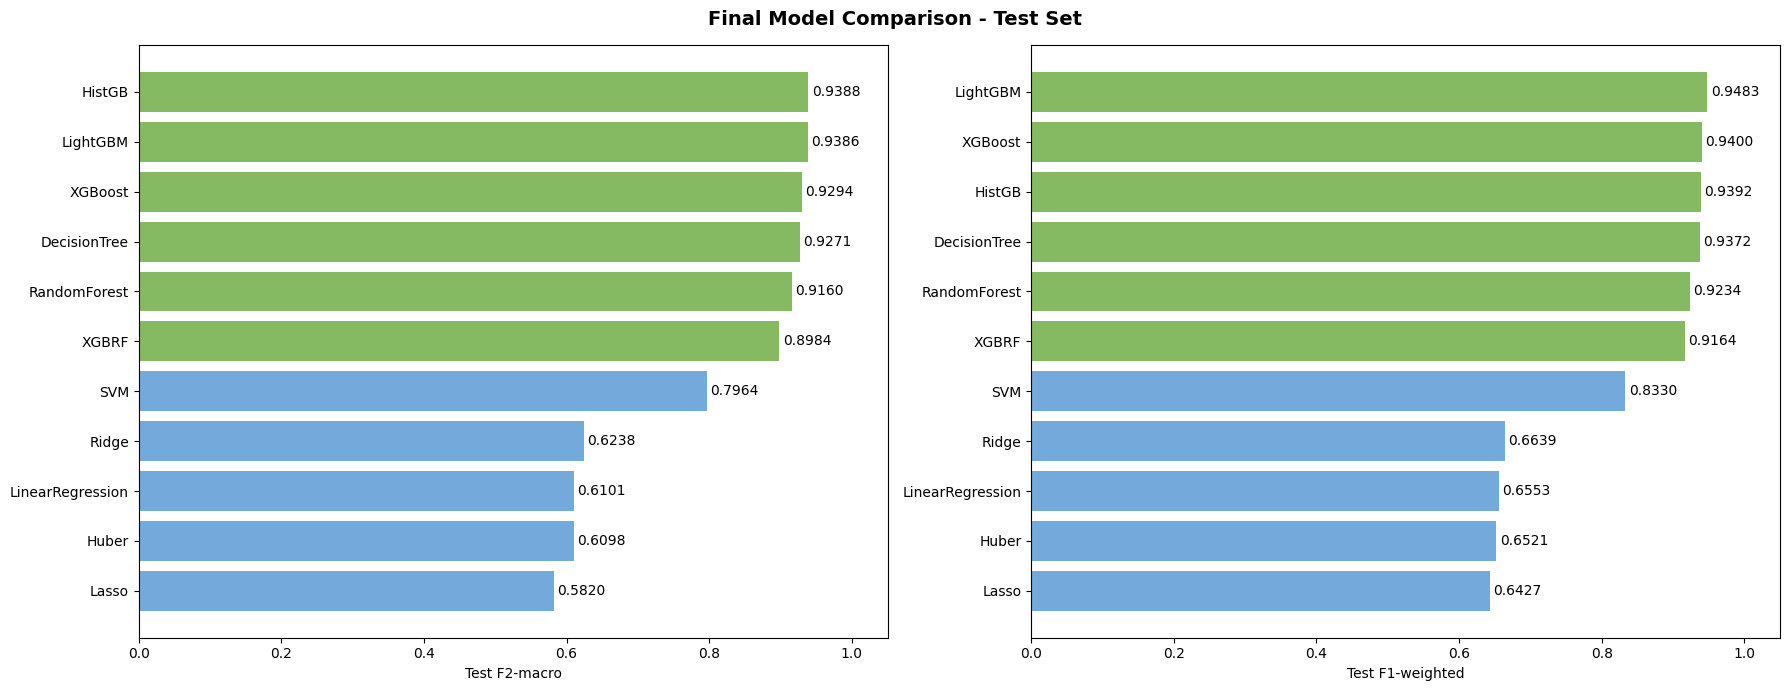

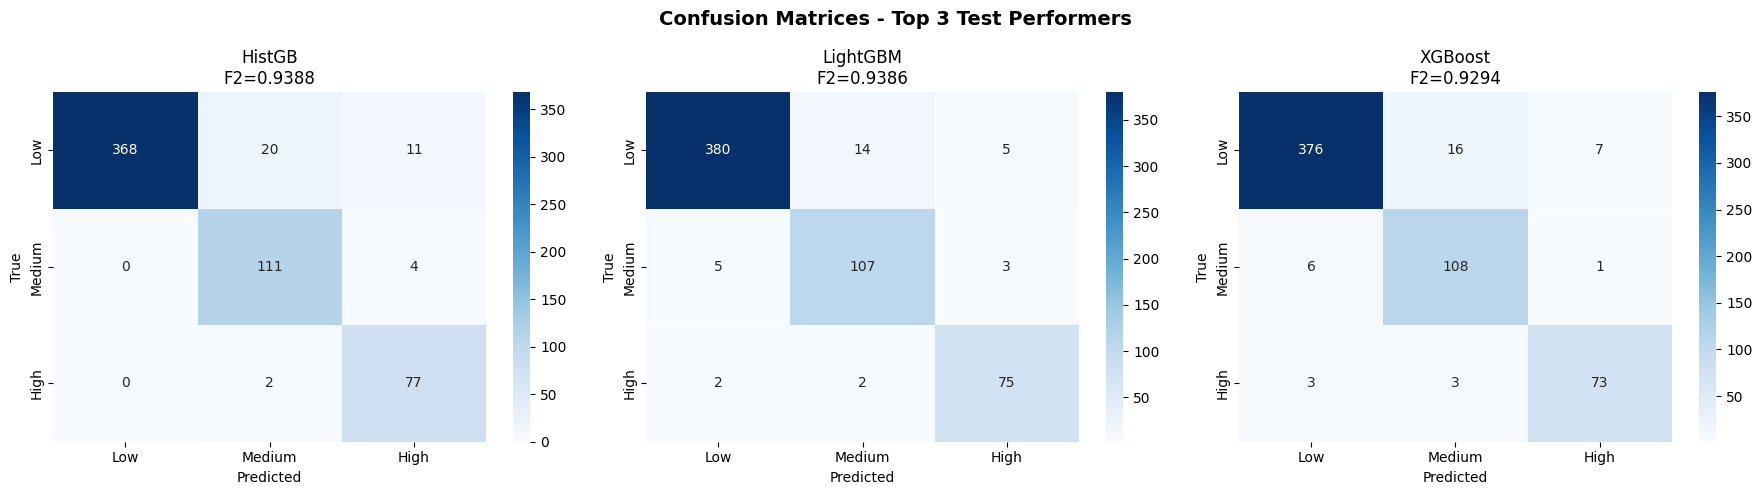

In [10]:
# CELL 9 - Final visualizations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Final Model Comparison - Test Set', fontsize=14, fontweight='bold')
colors_map = {'Tree': '#70AD47', 'Linear': '#5B9BD5'}

for ax, metric in zip(axes, ['Test F2-macro', 'Test F1-weighted']):
    df_plot = df_results.sort_values(metric)
    colors = [colors_map[value] for value in df_plot['Pipeline']]
    bars = ax.barh(df_plot['Model'], df_plot[metric], color=colors, alpha=0.85)
    ax.set_xlabel(metric)
    ax.set_xlim(0, 1.05)
    for bar, value in zip(bars, df_plot[metric]):
        ax.text(value + 0.005, bar.get_y() + bar.get_height() / 2, f'{value:.4f}', va='center')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

top3 = df_results.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - Top 3 Test Performers', fontsize=14, fontweight='bold')
for ax, model_name in zip(axes, top3):
    cm = np.asarray(detailed_metrics[model_name]['confusion_matrix'])
    sns.heatmap(cm, ax=ax, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'])
    ax.set_title(f"{model_name}\nF2={detailed_metrics[model_name]['f2_macro']:.4f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrices_top3.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# CELL 10 - Save final reports
df_results.to_csv(RESULTS_DIR / 'final_metrics.csv', index=False)
df_perclass.to_csv(RESULTS_DIR / 'per_class_metrics.csv', index=False)

save_data = {}
for model_name, metrics in detailed_metrics.items():
    split_metrics = all_results[model_name]
    save_data[model_name] = {
        **split_metrics,
        'best_params': metrics['best_params'],
        'artifact_metadata': metrics['metadata'],
        'confusion_matrix': metrics['confusion_matrix'],
        'per_class': {
            class_name: {
                key: metrics['per_class'][class_name][key]
                for key in ['precision', 'recall', 'f1-score', 'support']
            }
            for class_name in ['Low', 'Medium', 'High']
        },
    }

with open(RESULTS_DIR / 'detailed_metrics.json', 'w', encoding='utf8') as handle:
    json.dump(save_data, handle, indent=2)

print(f'Final reports saved to {RESULTS_DIR}')
print('Model checkpoints:')
for path in sorted(MODELS_DIR.glob('*.pkl')):
    print(f'  {path.name}: {path.stat().st_size / 1024 / 1024:.1f} MB')

Final reports saved to /kaggle/working/flood-forecast/results/final
Model checkpoints:
  DecisionTree.pkl: 0.0 MB
  HistGB.pkl: 1.3 MB
  Huber.pkl: 0.0 MB
  Lasso.pkl: 0.0 MB
  LightGBM.pkl: 1.5 MB
  LinearRegression.pkl: 0.0 MB
  RandomForest.pkl: 2.5 MB
  Ridge.pkl: 0.0 MB
  SVM.pkl: 0.3 MB
  XGBRF.pkl: 7.6 MB
  XGBoost.pkl: 1.5 MB


In [12]:
# CELL 11 - Final summary
best_test_name = df_results.iloc[0]['Model']
best_cv_name = df_results.sort_values('CV F2-macro', ascending=False).iloc[0]['Model']

print(f'Best model selected by train-only tuning CV: {best_cv_name}')
print(f'Best test performer (reporting only): {best_test_name}')
print('\nFull final ranking:')
print(df_results.to_string(index=False, float_format=lambda value: f'{value:.4f}'))

best_metrics = detailed_metrics[best_test_name]
print(f'\nPer-class test performance for {best_test_name}:')
for class_name in ['Low', 'Medium', 'High']:
    values = best_metrics['per_class'][class_name]
    print(
        f"  {class_name:6s} precision={values['precision']:.3f} "
        f"recall={values['recall']:.3f} f1={values['f1-score']:.3f}"
    )

Best model selected by train-only tuning CV: HistGB
Best test performer (reporting only): HistGB

Full final ranking:
 Test Rank            Model Pipeline  CV F2-macro  Train F2-macro  Train F1-weighted  Test F2-macro  Test F1-weighted  F2 gap  F1 gap
         1           HistGB     Tree       0.9338          0.9639             0.9568         0.9388            0.9392  0.0251  0.0176
         2         LightGBM     Tree       0.9098          0.9868             0.9886         0.9386            0.9483  0.0483  0.0403
         3          XGBoost     Tree       0.9020          0.9772             0.9790         0.9294            0.9400  0.0477  0.0390
         4     DecisionTree     Tree       0.8966          0.9469             0.9597         0.9271            0.9372  0.0198  0.0226
         5     RandomForest     Tree       0.9003          0.9395             0.9429         0.9160            0.9234  0.0235  0.0195
         6            XGBRF     Tree       0.9030          0.9493             